# LensWord — Model Training

This notebook builds and trains the Bidirectional LSTM model on the
preprocessed Amazon review data. It loads the saved tensors from the
preprocessing notebook, defines the model architecture, runs the training
loop, and saves the best model based on validation accuracy.

Before running: make sure `02_preprocessing_lensword.ipynb` has been run
first and that all `.pt` tensor files and `word2idx.pkl` exist inside
the `data/` folder.

In [1]:
# Set random seeds for reproducible results 
import torch 
import numpy as np 
import random 
SEED = 42 
torch.manual_seed(SEED) 
np.random.seed(SEED) 
random.seed(SEED) 
print(f"Random seed set to {SEED} for reproducible results")

Random seed set to 42 for reproducible results


In [2]:
# Import all necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add project root to path so we can import config.py
sys.path.append(os.path.abspath('..'))
from src.config import *

In [3]:
# Load SMOTE balanced training tensors
X_train = torch.load('../data/X_train_smote.pt')
y_train = torch.load('../data/y_train_smote.pt')

print("SMOTE balanced training data loaded!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

SMOTE balanced training data loaded!
X_train shape: torch.Size([15165, 50])
y_train shape: torch.Size([15165])


In [4]:
import os
import shutil

# Save old results before overwriting with SMOTE version
if os.path.exists('../models/lensword_model.pt'):
    shutil.copy('../models/lensword_model.pt',
                '../models/lensword_model_before_smote.pt')
   
if os.path.exists('../models/training_curves.png'):
    shutil.copy('../models/training_curves.png',
                '../models/training_curves_before_smote.png')

print("Old model and curves backed up!")


Old model and curves backed up!


In [5]:
# Load all preprocessed tensors saved from the preprocessing notebook
X_train = torch.load('../data/X_train.pt')
X_val = torch.load('../data/X_val.pt')
X_test = torch.load('../data/X_test.pt')
y_train = torch.load('../data/y_train.pt')
y_val = torch.load('../data/y_val.pt')
y_test = torch.load('../data/y_test.pt')

print("Tensors loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

Tensors loaded successfully!
X_train shape: torch.Size([11361, 50])
X_val shape:   torch.Size([2272, 50])
X_test shape:  torch.Size([1516, 50])


In [6]:
# Create DataLoaders to feed data to the model in batches
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully!")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

DataLoaders created successfully!
Training batches:   356
Validation batches: 71
Test batches:       48


In [7]:
# Define the Bidirectional LSTM model architecture
class LensWordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers,
                 num_classes, dropout):
        super(LensWordLSTM, self).__init__()

        # Embedding layer converts word indices to vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True,
                            dropout=dropout)

        # Dropout for regularization to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        # Final fully connected layer for classification
        # hidden_dim * 2 because bidirectional means two directions
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

print("Model architecture defined successfully!")


Model architecture defined successfully!


In [8]:
# Initialize the model with our config settings
model = LensWordLSTM(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

# Print model summary
print("Model initialized successfully!")
print(f"\nModel Architecture:")
print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model initialized successfully!

Model Architecture:
LensWordLSTM(
  (embedding): Embedding(4340, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Total Parameters: 872,451


In [9]:
# Define loss function, optimizer and learning rate scheduler

# Class weights to handle imbalanced data
class_weights = torch.tensor([3.0, 5.0, 1.0])  # Negative, Neutral, Positive
##class_weights = torch.tensor([5.0, 5.0, 1.0])  # Negative increaded from 3.0 to 5.0 model colapesed here
# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
# Reduces learning rate by half if val loss doesn't improve for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)



print("Loss function, optimizer and scheduler defined!")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Scheduler: ReduceLROnPlateau (patience=2, factor=0.5)")

Loss function, optimizer and scheduler defined!
Learning Rate: 0.001
Scheduler: ReduceLROnPlateau (patience=2, factor=0.5)


In [10]:
# Define the training function
# This runs one complete pass through the training data

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
   
    for batch_X, batch_y in loader:
        # Clear previous gradients
        optimizer.zero_grad()
       
        # Forward pass - get predictions
        predictions = model(batch_X)
       
        # Calculate loss
        loss = criterion(predictions, batch_y)
       
        # Backward pass - calculate gradients
        loss.backward()
       
        # Update model weights
        optimizer.step()
       
        # Track accuracy
        total_loss += loss.item()
        predicted_labels = predictions.argmax(dim=1)
        correct += (predicted_labels == batch_y).sum().item()
        total += batch_y.size(0)
   
    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

print("Training function defined!")


Training function defined!


In [11]:
# Define the validation function
# This checks how well the model performs on unseen data

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
   
    with torch.no_grad():
        for batch_X, batch_y in loader:
            # Forward pass only - no weight updates
            predictions = model(batch_X)
           
            # Calculate loss
            loss = criterion(predictions, batch_y)
           
            # Track accuracy
            total_loss += loss.item()
            predicted_labels = predictions.argmax(dim=1)
            correct += (predicted_labels == batch_y).sum().item()
            total += batch_y.size(0)
   
    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

print("Validation function defined!")

Validation function defined!


In [12]:
import os
os.makedirs('../models',exist_ok=True)

In [13]:
import os
print("Current directory:", os.getcwd())
print("Models folder exists:", os.path.exists('../models'))
print("Contents of parent folder:")
print(os.listdir('..'))

Current directory: C:\Users\Administrator\Desktop\Apeiron_ML_2026\Project 07\lensword\notebooks
Models folder exists: True
Contents of parent folder:
['.dockerignore', '.git', '.gitignore', '.venv', 'data', 'Dockerfile', 'index.html', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [14]:
print(repr(MODEL_SAVE_PATH))

'../models/lensword_model.pt'


In [15]:
# Override model save path
MODEL_SAVE_PATH = '../models/lensword_model.pt'

# Make sure models folder exists
import os
os.makedirs('../models', exist_ok=True)

# Train the model for NUM_EPOCHS epochs
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_accuracy = 0

# Early stopping settings
patience = 5
#patience = 3
epochs_no_improve = 0
early_stop = False

print("Starting training...")
print(f"Early stopping patience: {patience} epochs")
print("=" * 65)

for epoch in range(NUM_EPOCHS):
    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
   
    # Evaluate on validation set
    val_loss, val_acc = evaluate(model, val_loader, criterion)
   
    # Step the learning rate scheduler based on validation loss
    scheduler.step(val_loss)
   
    # Save metrics for plotting later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
   
    # Save the best model based on validation accuracy
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved = "✅ Best model saved!"
    else:
        epochs_no_improve += 1
        saved = f"⚠️ No improvement ({epochs_no_improve}/{patience})"
   
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
   
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f} {saved}")
   
    # Check early stopping condition
    if epochs_no_improve >= patience:
        print("\n⛔ Early stopping triggered! No improvement in validation accuracy.")
        break

print("=" * 65)
print(f"Training complete! Best Validation Accuracy: {best_val_accuracy:.2f}%")

Starting training...
Early stopping patience: 5 epochs
Epoch 01/15 | Train Loss: 0.9253 | Train Acc: 42.76% | Val Loss: 0.8559 | Val Acc: 51.54% | LR: 0.001000 ✅ Best model saved!
Epoch 02/15 | Train Loss: 0.7825 | Train Acc: 56.95% | Val Loss: 0.7820 | Val Acc: 57.48% | LR: 0.001000 ✅ Best model saved!
Epoch 03/15 | Train Loss: 0.6309 | Train Acc: 67.43% | Val Loss: 0.6848 | Val Acc: 65.76% | LR: 0.001000 ✅ Best model saved!
Epoch 04/15 | Train Loss: 0.4647 | Train Acc: 75.71% | Val Loss: 0.6150 | Val Acc: 73.28% | LR: 0.001000 ✅ Best model saved!
Epoch 05/15 | Train Loss: 0.2943 | Train Acc: 84.44% | Val Loss: 0.5897 | Val Acc: 77.86% | LR: 0.001000 ✅ Best model saved!
Epoch 06/15 | Train Loss: 0.1851 | Train Acc: 90.22% | Val Loss: 0.6631 | Val Acc: 82.22% | LR: 0.001000 ✅ Best model saved!
Epoch 07/15 | Train Loss: 0.1495 | Train Acc: 92.07% | Val Loss: 0.5954 | Val Acc: 82.70% | LR: 0.001000 ✅ Best model saved!
Epoch 08/15 | Train Loss: 0.0858 | Train Acc: 95.41% | Val Loss: 0.656

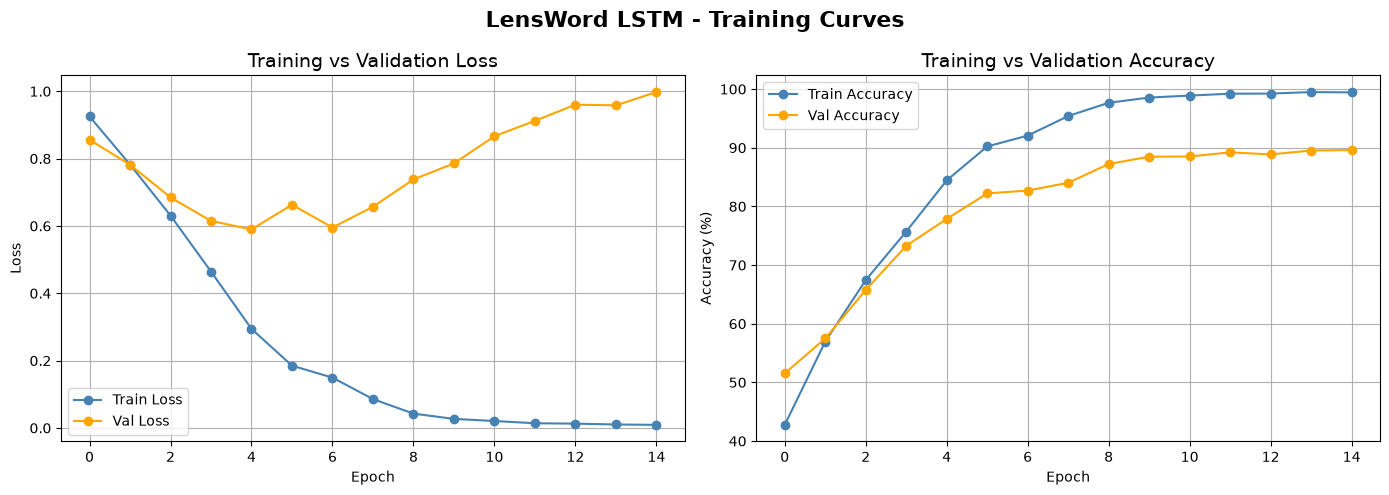

Training curves saved!


In [16]:
# Plot training and validation loss and accuracy curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_losses, label='Train Loss', color='steelblue', marker='o')
ax1.plot(val_losses, label='Val Loss', color='orange', marker='o')
ax1.set_title('Training vs Validation Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curves
ax2.plot(train_accuracies, label='Train Accuracy', color='steelblue', marker='o')
ax2.plot(val_accuracies, label='Val Accuracy', color='orange', marker='o')
ax2.set_title('Training vs Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('LensWord LSTM - Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/training_curves.png')
plt.show()

print("Training curves saved!")

In [17]:
# Final summary of training
print("=" * 45)
print("TRAINING SUMMARY - LensWord")
print("=" * 45)
print(f"Total Epochs Run:        {len(train_losses)}")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"Final Train Accuracy:    {train_accuracies[-1]:.2f}%")
print(f"Model saved to:          ../models/lensword_model.pt")
print("=" * 45)


TRAINING SUMMARY - LensWord
Total Epochs Run:        15
Best Validation Accuracy: 89.61%
Final Train Accuracy:    99.44%
Model saved to:          ../models/lensword_model.pt


In [18]:
"""# Train 3 separate models with different random seeds
# This creates an ensemble that averages out random variance

import torch
import numpy as np
import random

seeds = [42, 123, 7]
ensemble_models = []

for seed_num, seed in enumerate(seeds):
    print(f"\n{'='*65}")
    print(f"Training Model {seed_num + 1}/3 with seed={seed}")
    print(f"{'='*65}")
   
    # Set seed for this run
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
   
    # Create a fresh model
    model_i = LensWordLSTM(
        vocab_size=MAX_VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT
    )
   
    # Fresh optimizer and scheduler for this model
    optimizer_i = optim.Adam(model_i.parameters(), lr=LEARNING_RATE)
    scheduler_i = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_i, mode='min', factor=0.5, patience=2
    )
   
    best_val_acc_i = 0
    epochs_no_improve_i = 0
    patience_i = 5
   
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model_i, train_loader, optimizer_i, criterion)
        val_loss, val_acc = evaluate(model_i, val_loader, criterion)
        scheduler_i.step(val_loss)
       
        if val_acc > best_val_acc_i:
            best_val_acc_i = val_acc
            epochs_no_improve_i = 0
            torch.save(model_i.state_dict(), f'../models/lensword_model_seed{seed}.pt')
        else:
            epochs_no_improve_i += 1
       
        print(f"  Epoch {epoch+1:02d}/{NUM_EPOCHS} | Val Acc: {val_acc:.2f}%")
       
        if epochs_no_improve_i >= patience_i:
            print(f"  Early stopping at epoch {epoch+1}")
            break
   
    print(f"Model {seed_num + 1} Best Val Accuracy: {best_val_acc_i:.2f}%")
    ensemble_models.append(f'../models/lensword_model_seed{seed}.pt')

print(f"\n{'='*65}")
print("All 3 models trained!")
print(f"Saved models: {ensemble_models}")
print(f"{'='*65}")

_IncompleteInputError: incomplete input (722156743.py, line 1)